## 1. Data Pre-Processing
### Cleaning up the data fields

In [20]:
%pip install -r ../requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import wordcloud
import ipywidgets as widgets
from IPython.display import display, Markdown

In [22]:
challenges = '../output/sentiments/challenges.csv'
expectations = '../output/sentiments/expectations.csv'

In [ ]:
df_painpoints = pd.read_csv(challenges, engine='python', on_bad_lines='skip')
df_expectations = pd.read_csv(expectations, engine='python', on_bad_lines='skip')

# Normalize column names to avoid issues from hidden spaces in headers.
df_painpoints.columns = df_painpoints.columns.str.strip()
df_expectations.columns = df_expectations.columns.str.strip()

In [24]:
df_painpoints.shape, df_expectations.shape

((346, 2), (268, 2))

In [25]:
#drop the pain_points rows containing "Other", "IPS related"
df_painpoints = df_painpoints[~df_painpoints['Pain Point'].str.contains('Other|IPS related', case=False, na=False)]
df_expectations = df_expectations[~df_expectations['Expectation'].str.contains('Other|IPS related', case=False, na=False)]

In [26]:
df_painpoints.shape, df_expectations.shape

((346, 2), (268, 2))

In [27]:
# (optional )create new column 'pain_point_desc' and split on first ':' if present
# df_painpoints['pain_point_desc'] = ''
# mask = df_painpoints['Pain Point'].fillna('').str.contains(':')
# df_painpoints.loc[mask, 'pain_point_desc'] = df_painpoints.loc[mask, 'Pain Point'].str.split(':', n=1).str[1].str.strip()
# df_painpoints.loc[mask, 'Pain Point'] = df_painpoints.loc[mask, 'Pain Point'].str.split(':', n=1).str[0].str.strip()

# #create new column 'expectation_desc' and split on first ':' if present
# df_expectations['expectation_desc'] = ''
# mask = df_expectations['Expectation'].fillna('').str.contains(':')
# df_expectations.loc[mask, 'expectation_desc'] = df_expectations.loc[mask, 'Expectation'].str.split(':', n=1).str[1].str.strip()
# df_expectations.loc[mask, 'Expectation'] = df_expectations.loc[mask, 'Expectation'].str.split(':', n=1).str[0].str.strip()

In [28]:
# create a new column to represent the string length of the pain point and expectation
df_painpoints['word_count'] = df_painpoints['Pain Point'].str.split().str.len()
df_expectations['word_count'] = df_expectations['Expectation'].str.split().str.len()

In [29]:
df_painpoints.sample(5, random_state=42)

,,,,,Focus Group,Pain Point,word_count
CPC CPC,"Manual Financial Processes: Financial reconciliation, collections, and reporting require significant manual effort.",manual financial process financial reconciliation collection reporting require significant manual effort,positive,0.2023,-3,manual financial process financial reconciliat...,11
Assessment Assessment Supervisors,Seasonal Review Process: Permit monitoring and field review activities vary throughout the year based on the assessment calendar.,seasonal review process permit monitoring field review activity vary throughout year based assessment calendar,neutral,0.0,0,seasonal review process permit monitoring fiel...,14
DOCE Fire Prevention Bureau,"Too Many Systems: Staff use IPS, Camino, EPR, Compliance Engine, Outlook, spreadsheets, and paper planners.",many system staff use ip camino epr compliance engine outlook spreadsheet paper planner,neutral,0.0,-2,many system staff use ip camino epr compliance...,13
DOCE Supervisors,No Batch Processing: Large-scale updates and cleanup activities are difficult to perform.,batch processing update cleanup activity difficult perform,negative,-0.5719,-3,batch processing update cleanup activity diffi...,7
DOCE Housing Inspectors,No Global Case View: Difficult to review all active and closed cases associated with a property.,global case view difficult review active closed case associated property,positive,-0.25,-3,global case view difficult review active close...,10


In [30]:
df_expectations.sample(5, random_state=42)

,,,,,Focus Group,Expectation,word_count
DOCE Admin Aide,Create a more unified view of property and inspection information.,create unified view property inspection information,positive,0.6115,0,create unified view property inspection inform...,6
DOCE Fire Prevention Bureau,Better IPS-Camino-EPR Integration: Reduce duplicate work across systems.,better integration reduce duplicate work across system,positive,0.4404,5,better integration reduce duplicate work acros...,7
CPO Central Permit Office,Audit & User Tracking: Improve tracking of user actions and system activity.,audit user tracking improve tracking user action system activity,positive,0.4404,5,audit user tracking improve tracking user acti...,9
DOCE Supervisors,Improved Parcel History: Better display and organization of parcel-related information.,improved parcel history better display organization information,positive,0.7184,10,improved parcel history better display organiz...,7
DOCE Admin Aide,Improve access to ownership and property information.,improve access ownership property information,positive,0.4404,5,improve access ownership property information,5


In [31]:
# show the rows where word_count is less than 5 for pain points and expectations
df_painpoints[df_painpoints['word_count'] <= 4]

Focus Group  \
Focus Group                                Pain Point                                         processed_content                        label    VADER    Business Score   
CPO Central Permit Office                  Application & Review Challenges                    application review challenge             positive 0.0772                0   
CPO CPO Co-Ordinator                       System Performance & Usability                     system performance usability             neutral  0.0                   0   
                                           Scheduling & Communication Challenges              scheduling communication challenge       positive 0.0772                0   
DOCE Building Inspectors                   Ownership & Property Information                   ownership property information           neutral  0.0                   0   
DOCE CommercialPermitElectrical Inspectors System Performance & Usability                     system performance usability             neutral  0.0                   0   
                                           Searching Difficulties: Finding information can... searching difficulty finding information negative -0.296               -4   
                                           Data & Information Challenges                      data information challenge               positive 0.0772                0   
DOCE Admin Aide                            System Performance & Usability                     system performance usability             neutral  0.0                   0   
                                           Outlook and IPS schedules are not synchronized.    outlook ip schedule synchronized         neutral  0.0                   0   
                                           Finding specific cases can be difficult.           finding specific case difficult          negative -0.3612              -3   
                                           Save functions are inconsistent.                   save function inconsistent               positive 0.4939                0   
                                           Uploading documents can impact performance.        uploading document impact performance    neutral  0.0                   0   
                                           Ownership information can be difficult to verify.  ownership information difficult verify   negative -0.3612              -3   
                                           Training & Knowledge Challenges                    training knowledge challenge             positive 0.0772                0   
                                           Front-counter traffic can become overwhelming.     traffic become overwhelming              neutral  0.0                   0   
DOCE Supervisors                           Data & Information Issues                          data information issue                   neutral  0.0                  -2   
                                           System Performance & Usability                     system performance usability             neutral  0.0                   0   
                                           Contractor & Public Challenges                     contractor public challenge              positive 0.0772                0   
DOCE Office Manager                        Ownership & Contact Management                     ownership contact management             neutral  0.0                   0   
                                           Duplicate ownership and contact records.           duplicate ownership contact record       neutral  0.0                  -2   
                                           Ownership / Property Management                    ownership property management            neutral  0.0                   0   
                                           Parcel History can be difficult to navigate.       parcel history difficult navigate        negative -0.3612              -3   
                                           Historica

In [32]:
#drop the rows containing less than or equal to 4 words in pain_points and expectations
df_painpoints = df_painpoints[df_painpoints['word_count'] >= 4].drop(columns=['word_count'])
df_expectations = df_expectations[df_expectations['word_count'] >= 4].drop(columns=['word_count'])

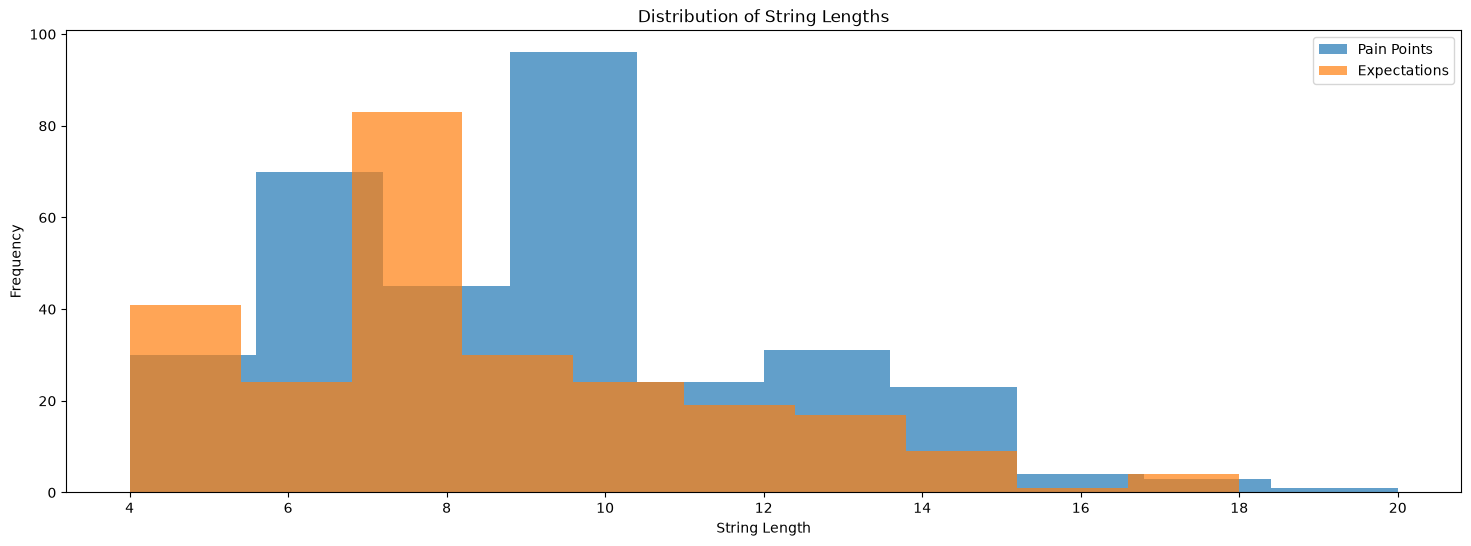

In [33]:
#plot the distribution of string lengths for pain points and expectations
plt.figure(figsize=(18, 6))
hist_pain = plt.hist(df_painpoints['Pain Point'].str.split().str.len(), alpha=0.7, label='Pain Points')
hist_expect = plt.hist(df_expectations['Expectation'].str.split().str.len(), alpha=0.7, label='Expectations')
plt.xlabel('String Length')
plt.ylabel('Frequency')
plt.title('Distribution of String Lengths')
plt.legend()

In [34]:
#drop the rows containing less than or equal to 4 words in pain_points and expectations
df_painpoints = df_painpoints[df_painpoints['Pain Point'].str.split().str.len() > 4]
df_expectations = df_expectations[df_expectations['Expectation'].str.split().str.len() > 4]

### Finder function

In [35]:
def get_pain_points(keyword, optional_keywords=None, sentiment=None):
    """
    Get pain points based on keywords.

    Parameters:
    keyword (str or list): The main keyword or keywords that must be present in the pain points.
    optional_keywords (list, optional): List of additional keywords that may also appear in the same record.
    sentiment (str, optional): The sentiment to filter by.

    Returns:
    DataFrame: Filtered DataFrame containing pain points that match the keywords.
    """
    required_keywords = keyword if isinstance(keyword, list) else [keyword]
    required_mask = df_painpoints['processed_content'].str.contains('|'.join(required_keywords), case=False, na=False)

    filtered_pain_points = df_painpoints[required_mask]

    if optional_keywords:
        optional_mask = filtered_pain_points['processed_content'].str.contains('|'.join(optional_keywords), case=False, na=False)
        filtered_pain_points = filtered_pain_points[optional_mask]

    if sentiment is not None:
        filtered_pain_points = filtered_pain_points[filtered_pain_points['label'] == sentiment]
    return filtered_pain_points

In [36]:
def get_expectations(keyword, optional_keywords=None, sentiment=None):
    """
    Get expectations based on keywords.

    Parameters:
    keyword (str or list): The main keyword or keywords to search for in the expectations.
    optional_keywords (list, optional): List of additional keywords to search for.
    sentiment (str, optional): The sentiment to filter by.

    Returns:
    DataFrame: Filtered DataFrame containing expectations that match the keywords.
    """
    keywords = keyword if isinstance(keyword, list) else [keyword]
    if optional_keywords:
        keywords.extend(optional_keywords)

    filtered_expectations = df_expectations[df_expectations['processed_content'].str.contains('|'.join(keywords), case=False, na=False)]
    if sentiment is not None:
        filtered_expectations = filtered_expectations[filtered_expectations['label'] == sentiment]
    return filtered_expectations

In [37]:
df_painpoints.sample(5)

,,,,,Focus Group,Pain Point
DOCE Zoning,"Scattered Project Information: Project documents, approvals, and historical records are distributed across multiple systems, making it difficult to view complete project history.",scattered project information project document approval historical record distributed across multiple system making difficult view complete project history,positive,-0.3612,-8,scattered project information project document...
NBD NBD Internal,Improved Cross-Case Visibility: Allow users to view related information across multiple cases from a single location.,improved visibility allow user view related information across multiple case single location,positive,0.6124,-2,improved visibility allow user view related in...
DOCE Building Inspectors,Tickle Dates Can Be Missed: Reminder dates can be overlooked or lost.,tickle date missed reminder date overlooked lost,negative,-0.5574,0,tickle date missed reminder date overlooked lost
CPO CPO Co-Ordinator,System Crashes: IPS crashes during high-volume processing activities.,system crash ip crash processing activity,negative,0.0,0,system crash ip crash processing activity
BAA BAA Ops,Improved Ticket Visibility: Show cases with open violations or fines without opening each individual record.,improved ticket visibility show case open violation fine without opening individual record,positive,-0.0772,0,improved ticket visibility show case open viol...


In [38]:
IPS_crashes = get_pain_points(['IPS'], optional_keywords=['crash', 'crashing','freezing', 'lag', 'slow', 'unresponsive', 'stuck', 'hang', 'freeze', 'navigat', 'interface', 'in-field', 'infield', 'in field', 'dashboard'], sentiment='negative') 
print(f"Total number of pain points related to IPS crashing issues: {len(IPS_crashes)}")

KeyError: 'processed_content'

In [ ]:
#store this as csv files for further analysis
df_painpoints.to_csv('../output/cleaned_challenges.csv', index=False)
df_expectations.to_csv('../output/cleaned_expectations.csv', index=False)

In [ ]:
#function to calculate amount of times a keyword appears in a pain point 
def count_keyword_occurrences(keyword, case_sensitive=False):
    return df_painpoints.loc[
        df_painpoints['Pain Point'].str.contains(keyword, case=case_sensitive, na=False)
    ].shape[0]

In [ ]:
count_keyword_occurrences('crash|Crash|freez|Freez|slow|Slow|lag|Lag|hang|Hang|unresponsive|Unresponsive|shutdown|Shutdown|freeze|Freeze|lock|Lock|stuck|Stuck|')

In [ ]:
# display the records where the pain point contains the keyword 'Crashes'
df_painpoints[df_painpoints['Pain Point'].str.contains('crash|Crash|freez|Freez|slow|Slow|lag|Lag|hang|Hang|unresponsive|Unresponsive|shutdown|Shutdown|freeze|Freeze|lock|Lock|stuck|Stuck|', na=False)]

In [ ]:
count_keyword_occurrences('many system|multiple system', case_sensitive=False)

In [ ]:
df_painpoints[df_painpoints['Pain Point'].str.contains('many system|multiple system', na=False)]